# Cetacean MLP — Calibrated LODO (Vector Scaling + PR-Threshold)

Four prediction strategies compared in LODO:

- **argmax** — standard softmax argmax (baseline)
- **temperature** — single scalar T, fit on full val
- **vector scaling** — per-class `w_c * logit_c + b_c`, fit on full val with class weighting
- **pr_thresh** — per-species F1-optimal threshold fit on val via precision-recall curve;
  argmax among species that clear their threshold, fallback to background if none do

### Inter-species confusion definition
A prediction counts as inter-species confusion if the true label is a species and
the predicted label is ANY species in the training vocabulary.
`sp_hallucination_rate` = fraction of species test rows where prediction is a species
absent from the test fold entirely.

**Rule:** the test set is never used for calibration or threshold fitting.

## 0. Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    accuracy_score, balanced_accuracy_score,
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42); torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}  torch: {torch.__version__}")

device: cuda  torch: 2.5.1+cu121


In [3]:
IN_DIR  = Path('/data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs')
PROJ_IN = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input')
OUT_DIR = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/calibrated_lodo')
OUT_DIR.mkdir(exist_ok=True, parents=True)

META_PATH = IN_DIR / 'meta_all_with_taxonomy.parquet'
X_PATH    = PROJ_IN / 'X_all.npy'

print(f"meta:  {META_PATH}  exists={META_PATH.exists()}")
print(f"X_all: {X_PATH}     exists={X_PATH.exists()}")
print(f"out:   {OUT_DIR.resolve()}")

meta:  /data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs/meta_all_with_taxonomy.parquet  exists=True
X_all: /data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input/X_all.npy     exists=True
out:   /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/calibrated_lodo


In [7]:
meta_all = pd.read_parquet(META_PATH)
X_all    = np.load(X_PATH, mmap_mode='r')

EXCLUDE = {'ALNITAK_CAVANILLES', 'FREMANTLE', 'ECOSS_enhanced', 'MONISH','WATKINS', 'ECOSS_annot' }
meta_all = meta_all[~meta_all['dataset'].isin(EXCLUDE)].reset_index(drop=True)

print(f"meta_all: {len(meta_all):,} rows")

# sanity check: row values must still be valid X_all indices
assert meta_all['row'].max() < len(X_all)
assert meta_all['row'].min() >= 0
assert meta_all['row'].nunique() == len(meta_all), "duplicate row indices — unexpected"


meta_all: 238,682 rows


In [8]:

print(f"X_all:    {X_all.shape}  dtype={X_all.dtype}")

assert 'row' in meta_all.columns
assert 'group_key' in meta_all.columns
assert meta_all['row'].max() < len(X_all)
for c in ['label_t1','label_t2','label_t3','label_t4','label_t5']:
    assert c in meta_all.columns, f"missing: {c}"

ALL_DATASETS = sorted(meta_all['dataset'].unique().tolist())
print(f"datasets ({len(ALL_DATASETS)}): {ALL_DATASETS}")

X_all:    (247630, 1536)  dtype=float32
datasets (6): ['Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_testtrain', 'OLTREMARE']


## 1. Label frames

In [9]:
def build_l2(row):
    t2 = row['label_t2']
    if pd.notna(t2) and t2 in ('odontocete','mysticete','anthropogenic','background'):
        return t2
    t1 = row['label_t1']
    if pd.notna(t1) and t1 == 'non_mammal': return 'background'
    return None

def build_l4(row):
    t4 = row['label_t4']
    if pd.notna(t4): return t4
    t1 = row['label_t1']; t2 = row['label_t2']
    if pd.notna(t1) and t1 == 'non_mammal': return 'background'
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'): return 'background'
    return None

meta_l2 = meta_all.copy(); meta_l2['label'] = meta_l2.apply(build_l2, axis=1)
meta_l2 = meta_l2.dropna(subset=['label']).copy()
print(f"\nL2: {len(meta_l2):,} rows"); print(meta_l2['label'].value_counts().to_string())

meta_l4 = meta_all.copy(); meta_l4['label'] = meta_l4.apply(build_l4, axis=1)
meta_l4 = meta_l4.dropna(subset=['label']).copy()
print(f"\nL4: {len(meta_l4):,} rows"); print(meta_l4['label'].value_counts().to_string())
print()
print(pd.crosstab(meta_l4['dataset'], meta_l4['label']).to_string())


L2: 238,682 rows
label
background       175362
anthropogenic     33585
odontocete        29735

L4: 238,682 rows
label
background                208947
Orcinus_orca               21718
Tursiops_truncatus          6781
Delphinus_delphis           1190
Globicephala_melas            26
Physeter_macrocephalus        20

label            Delphinus_delphis  Globicephala_melas  Orcinus_orca  Physeter_macrocephalus  Tursiops_truncatus  background
dataset                                                                                                                     
Adriatic_Sea                     0                   0             0                       0                 942         238
DCLDE_2026                       0                   0         21696                       0                   0      152842
DOLPHINFREE                   1150                   0             0                       0                   0        2140
DRYAD                            0                   0  

We drop what only exists in 1 dataset: globicephala melas + physeter macrocephalus

In [10]:
# Drop underrepresented species from L4
L4_DROP_SPECIES = {'Globicephala_melas', 'Physeter_macrocephalus'}
meta_l4 = meta_l4[~meta_l4['label'].isin(L4_DROP_SPECIES)].copy()

print(f"L4 after drop: {len(meta_l4):,} rows")
print(meta_l4['label'].value_counts().to_string())
print()
print(pd.crosstab(meta_l4['dataset'], meta_l4['label']).to_string())

# Sanity checks
assert meta_l4['row'].max() < len(X_all)
assert not meta_l4['label'].isin(L4_DROP_SPECIES).any()
assert meta_l4['label'].nunique() == 4, f"expected 4 classes, got {meta_l4['label'].nunique()}"

L4 after drop: 238,636 rows
label
background            208947
Orcinus_orca           21718
Tursiops_truncatus      6781
Delphinus_delphis       1190

label            Delphinus_delphis  Orcinus_orca  Tursiops_truncatus  background
dataset                                                                         
Adriatic_Sea                     0             0                 942         238
DCLDE_2026                       0         21696                   0      152842
DOLPHINFREE                   1150             0                   0        2140
DRYAD                            0             0                2916        3854
ECOSS_testtrain                 40            22                  19       35917
OLTREMARE                        0             0                2904       13956


## 2. MLP

In [11]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)   # raw logits


def train_mlp(Xtr, ytr, Xva, yva, n_classes,
              hidden=(512,256), dropout=0.3, lr=1e-3, weight_decay=1e-4,
              batch_size=1024, epochs=40, patience=6, class_weight=True):
    model = MLP(Xtr.shape[1], n_classes, hidden=hidden, dropout=dropout).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if class_weight:
        counts = np.bincount(ytr, minlength=n_classes).astype(np.float32)
        w      = counts.sum() / (n_classes * np.clip(counts, 1, None))
        crit   = nn.CrossEntropyLoss(
            weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))
    else:
        crit = nn.CrossEntropyLoss()
    tr_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                       batch_size=batch_size, shuffle=True,  num_workers=0)
    va_dl = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)),
                       batch_size=batch_size, shuffle=False, num_workers=0)
    best_f1, best_state, bad = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval(); preds, trues = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
                trues.append(yb.numpy())
        va_f1 = f1_score(np.concatenate(trues), np.concatenate(preds),
                         average='macro', zero_division=0)
        if va_f1 > best_f1 + 1e-4:
            best_f1    = va_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, best_f1


def get_logits(model, X, batch_size=2048):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            out.append(model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out, axis=0)

## 3. Calibrators

### Temperature scaling
`softmax(logits / T)` — single scalar, fit on full val set.  
Does not change argmax but fixes probability magnitudes.

### Vector scaling
`softmax(w * logits + b)` — per-class scale and bias.  
**L4 / L2:** fit on species-positive val rows only (removes background dominance).  
**L1 binary:** fit on full val — species-only filtering degenerates when there
are only 2 classes (one of which IS the species class).

In [12]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))
    def forward(self, logits): return logits / self.log_T.exp()
    def fit(self, logits_val, y_val, lr=0.01, max_iter=200):
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)
        opt = torch.optim.LBFGS([self.log_T], lr=lr, max_iter=max_iter)
        def closure():
            opt.zero_grad()
            F.cross_entropy(self.forward(logits_t), labels_t).backward()
            return F.cross_entropy(self.forward(logits_t), labels_t)
        opt.step(closure)
        return self
    @property
    def T(self): return self.log_T.exp().item()


class VectorScaler(nn.Module):
    """
    Per-class scale + bias: calibrated_logit_c = w_c * logit_c + b_c
    Optimized across ALL validation data using inverse frequency weighting 
    to handle class imbalance without discarding background profiles.
    """
    def __init__(self, n_classes):
        super().__init__()
        self.w = nn.Parameter(torch.ones(n_classes))   # init: identity
        self.b = nn.Parameter(torch.zeros(n_classes))

    def forward(self, logits):
        return logits * self.w + self.b

    def fit(self, logits_val, y_val, lr=0.01, max_iter=500, l2=1e-3):
        """
        logits_val : (N, C) val logits
        y_val      : (N,) integer labels
        l2         : L2 regularisation pulling w→1, b→0
        """
        # Do NOT filter out background rows. Convert the complete validation set to tensors.
        logits_t = torch.tensor(logits_val, dtype=torch.float32)
        labels_t = torch.tensor(y_val,      dtype=torch.long)

        # Calculate class weights directly from the validation labels to counter imbalance
        counts = np.bincount(y_val, minlength=self.w.shape[0]).astype(np.float32)
        weights = counts.sum() / (self.w.shape[0] * np.clip(counts, 1, None))
        class_weights_t = torch.tensor(weights, dtype=torch.float32)

        opt = torch.optim.LBFGS([self.w, self.b], lr=lr, max_iter=max_iter)

        def closure():
            opt.zero_grad()
            cal_logits = self.forward(logits_t)
            
            # Use class weights here so rare species are balanced against the background class
            nll = F.cross_entropy(cal_logits, labels_t, weight=class_weights_t)
            
            # L2 regularisation: keep w close to 1, b close to 0
            reg = l2 * ((self.w - 1).pow(2).sum() + self.b.pow(2).sum())
            loss = nll + reg
            loss.backward()
            return loss

        opt.step(closure)
        return self

def calibrate_and_predict(logits, calibrator):
    with torch.no_grad():
        cal = calibrator(torch.tensor(logits, dtype=torch.float32))
        proba = F.softmax(cal, dim=1).numpy()
    return proba.argmax(axis=1), proba

## 4. Metrics

### Corrected inter-species confusion

A prediction is counted as inter-species confusion if:
- true label is a **species** (not background), AND
- predicted label is **any species in the training vocabulary** — including
  species with zero rows in the test fold.

Additionally: `sp_hallucination_rate` = fraction of species test rows where
the model predicted a species that has **zero true positives in this test fold**.
This is the worst deployment error: confidently asserting a species that is
entirely absent from the recording context.

In [13]:
def compute_metrics(y_true, y_pred, labels_present, n_classes):
    all_labels = list(range(n_classes))
    return {
        'test_macro_f1':            float(f1_score(y_true, y_pred, average='macro',
                                                   labels=labels_present, zero_division=0)),
        'test_macro_f1_full_vocab': float(f1_score(y_true, y_pred, average='macro',
                                                   labels=all_labels, zero_division=0)),
        'test_weighted_f1':         float(f1_score(y_true, y_pred, average='weighted',
                                                   labels=labels_present, zero_division=0)),
        'test_accuracy':            float(accuracy_score(y_true, y_pred)),
        'test_balanced_acc':        float(balanced_accuracy_score(y_true, y_pred)),
    }


def compute_species_metrics(y_true, y_pred, class_names, bg_label):
    """
    Metrics on species-only test rows (true label != background).

    Inter-species confusion: predicted ANY species in the training vocab
    but it was the wrong one — including species absent from the test fold.

    Hallucination rate: predicted a species that has ZERO true positives
    in this test fold (model asserts a species that isn't there at all).
    """
    bg_idx     = class_names.index(bg_label) if bg_label in class_names else -1
    # All species indices in the FULL training vocabulary
    all_sp_idx = set(i for i, c in enumerate(class_names) if i != bg_idx)

    sp_mask    = (y_true != bg_idx)
    sp_present = sorted(np.unique(y_true[sp_mask]).tolist())   # test-present only
    sp_absent  = all_sp_idx - set(sp_present)                  # in vocab but not in test

    if sp_mask.sum() == 0:
        return {k: None for k in [
            'sp_macro_f1','sp_recall','sp_precision','sp_balanced_acc',
            'sp_inter_confusion_rate','sp_hallucination_rate','sp_n_rows'
        ]}

    yt = y_true[sp_mask]
    yp = y_pred[sp_mask]
    n  = len(yt)

    # Inter-species confusion: wrong species predicted (vocab-wide)
    inter_conf   = float(((yp != yt) & np.isin(yp, list(all_sp_idx))).sum() / n)

    # Hallucination: predicted a species absent from this test fold
    hallucination = float(np.isin(yp, list(sp_absent)).sum() / n)

    return {
        'sp_macro_f1':             float(f1_score(yt, yp, average='macro',
                                                  labels=sp_present, zero_division=0)),
        'sp_recall':               float(recall_score(yt, yp, average='macro',
                                                      labels=sp_present, zero_division=0)),
        'sp_precision':            float(precision_score(yt, yp, average='macro',
                                                         labels=sp_present, zero_division=0)),
        'sp_balanced_acc':         float(balanced_accuracy_score(yt, yp)),
        'sp_inter_confusion_rate': inter_conf,
        'sp_hallucination_rate':   hallucination,
        'sp_n_rows':               int(n),
    }


def per_class_f1(y_true, y_pred, class_names):
    n   = len(class_names)
    f1s = f1_score(y_true, y_pred, labels=list(range(n)), average=None, zero_division=0)
    return {class_names[i]: float(f1s[i]) for i in range(n)}

## 5. LODO runner

## 3b. PR-threshold calibrator

For each species class, sweep all unique probability values on the val set
and pick the threshold that maximises per-class F1.
At inference, a row is assigned the highest-scoring species that clears its threshold;
if no species qualifies the row falls back to background.

In [14]:
from sklearn.metrics import precision_recall_curve

def fit_pr_thresholds(proba_val, y_val, class_names, bg_idx, min_thr=0.01):
    """
    Fit per-species F1-optimal thresholds on val probabilities.
    Returns dict: class_name -> threshold.
    Background gets threshold 0.0 (always qualifies as fallback).
    """
    thresholds = {}
    for cls_idx, cls_name in enumerate(class_names):
        if cls_idx == bg_idx:
            thresholds[cls_name] = 0.0
            continue
        y_bin = (y_val == cls_idx).astype(int)
        if y_bin.sum() == 0:
            thresholds[cls_name] = 0.5
            continue
        precs, recs, thrs = precision_recall_curve(y_bin, proba_val[:, cls_idx])
        f1s  = 2 * precs * recs / np.clip(precs + recs, 1e-9, None)
        f1s  = f1s[:-1]   # trailing point has no threshold
        valid = thrs >= min_thr
        if valid.sum() == 0:
            thresholds[cls_name] = 0.5
            continue
        best = np.argmax(f1s[valid])
        thresholds[cls_name] = float(thrs[valid][best])
    return thresholds


def predict_with_pr_thresholds(proba, class_names, thresholds, bg_idx):
    """
    For each row: take argmax among classes that exceed their threshold.
    If nothing qualifies, fall back to background.
    """
    qualify = np.zeros(proba.shape, dtype=bool)
    for cls_idx, cls_name in enumerate(class_names):
        if cls_idx == bg_idx:
            qualify[:, cls_idx] = True   # bg always qualifies as fallback
            continue
        thr = thresholds.get(cls_name, 0.5)
        qualify[:, cls_idx] = proba[:, cls_idx] >= thr
    masked = np.where(qualify, proba, -np.inf)
    return masked.argmax(axis=1)


In [15]:
def split_train_val(meta_subset, val_size=0.12, random_state=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    tr_pos, va_pos = next(gss.split(np.zeros(len(meta_subset)),
                                    groups=meta_subset['group_key'].values))
    return tr_pos, va_pos


def run_calibrated_lodo(held_out, meta_df, label_col='label',
                        bg_label='background', species_only_fit=True,
                        min_train_per_class=5, val_size=0.12, verbose=True):
    train_meta = meta_df[meta_df['dataset'] != held_out].copy()
    test_meta  = meta_df[meta_df['dataset'] == held_out].copy()

    counts     = train_meta[label_col].value_counts()
    train_keep = set(counts[counts >= min_train_per_class].index)
    test_keep  = set(test_meta[label_col].unique()) & train_keep

    if verbose:
        print(f"\n  [{held_out}] train classes ({len(train_keep)}): {sorted(train_keep)}")
        print(f"  [{held_out}] test composition:")
        for c, n in test_meta[label_col].value_counts().items():
            mark = 'OK' if c in train_keep else 'NOT in train — dropped'
            print(f"      {c:35s} n={n:>6,}  ({mark})")

    if len(train_keep) < 2: return None
    if len(test_keep)  < 1: return None

    train_meta = train_meta[train_meta[label_col].isin(train_keep)].copy()
    test_meta  = test_meta [test_meta [label_col].isin(test_keep )].copy()

    le = LabelEncoder().fit(sorted(train_keep))
    train_meta = train_meta.assign(y=le.transform(train_meta[label_col].astype(str)))
    test_meta  = test_meta .assign(y=le.transform(test_meta [label_col].astype(str)))
    class_names = list(le.classes_)
    n_cls       = len(class_names)
    bg_idx      = class_names.index(bg_label) if bg_label in class_names else -1

    tr_pos, va_pos = split_train_val(train_meta, val_size=val_size)
    rows_tr = train_meta.iloc[tr_pos]['row'].values
    rows_va = train_meta.iloc[va_pos]['row'].values
    rows_te = test_meta['row'].values

    sc    = StandardScaler().fit(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xtr_s = sc.transform(np.asarray(X_all[rows_tr], dtype=np.float32))
    Xva_s = sc.transform(np.asarray(X_all[rows_va], dtype=np.float32))
    Xte_s = sc.transform(np.asarray(X_all[rows_te], dtype=np.float32))
    ytr   = train_meta.iloc[tr_pos]['y'].values.astype(np.int64)
    yva   = train_meta.iloc[va_pos]['y'].values.astype(np.int64)
    yte   = test_meta['y'].values

    sp_rows_val = int((yva != bg_idx).sum()) if bg_idx >= 0 else len(yva)
    if verbose:
        print(f"  [{held_out}] train={len(rows_tr):,}  val={len(rows_va):,}  "
              f"(sp_val={sp_rows_val:,})  test={len(rows_te):,}")

    t0             = time.time()
    model, best_va = train_mlp(Xtr_s, ytr, Xva_s, yva, n_classes=n_cls)
    elapsed        = time.time() - t0

    logits_va = get_logits(model, Xva_s)
    logits_te = get_logits(model, Xte_s)

    # A: argmax
    proba_raw = torch.softmax(torch.tensor(logits_te), dim=1).numpy()
    y_argmax  = proba_raw.argmax(axis=1)

    # B: temperature scaling
    temp_scaler = TemperatureScaler()
    temp_scaler.fit(logits_va, yva)
    y_temp, proba_temp = calibrate_and_predict(logits_te, temp_scaler)

    # C: vector scaling
    vec_scaler = VectorScaler(n_cls)
    vec_scaler.fit(logits_va, yva, l2=1e-3)
    y_vec, proba_vec = calibrate_and_predict(logits_te, vec_scaler)

    # D: PR-threshold (fit on raw val probs)
    proba_va_raw  = torch.softmax(torch.tensor(logits_va), dim=1).numpy()
    pr_thresholds = fit_pr_thresholds(proba_va_raw, yva, class_names, bg_idx)
    y_pr_thresh   = predict_with_pr_thresholds(proba_raw, class_names, pr_thresholds, bg_idx)

    if verbose:
        print(f"  [{held_out}] T={temp_scaler.T:.3f}")
        print(f"  [{held_out}] vector scales:")
        for cn, w, b in zip(class_names,
                            vec_scaler.w.detach().numpy(),
                            vec_scaler.b.detach().numpy()):
            print(f"      {cn:35s}  w={w:+.3f}  b={b:+.3f}")
        print(f"  [{held_out}] PR thresholds:")
        for cn, t in sorted(pr_thresholds.items(), key=lambda kv: kv[1]):
            n_val = int((yva == class_names.index(cn)).sum()) if cn in class_names else 0
            print(f"      {cn:35s}  thr={t:.3f}  n_val={n_val}")

    present = sorted(np.unique(yte).tolist())

    return {
        'held_out':              held_out,
        'class_names':           class_names,
        'n_classes':             n_cls,
        'bg_idx':                bg_idx,
        'n_train':               len(rows_tr),
        'n_val':                 len(rows_va),
        'n_val_species':         sp_rows_val,
        'n_test':                len(rows_te),
        'rows_te':               rows_te,
        'val_macro_f1':          float(best_va),
        'elapsed_s':             float(elapsed),
        'temperature':           float(temp_scaler.T),
        'vec_w':                 vec_scaler.w.detach().numpy().copy(),
        'vec_b':                 vec_scaler.b.detach().numpy().copy(),
        'pr_thresholds':         pr_thresholds,
        'yte':                   yte,
        'y_argmax':              y_argmax,
        'y_temp':                y_temp,
        'y_vec':                 y_vec,
        'y_pr_thresh':           y_pr_thresh,
        'proba_raw':             proba_raw,
        'proba_temp':            proba_temp,
        'proba_vec':             proba_vec,
        'metrics_argmax':        compute_metrics(yte, y_argmax,    present, n_cls),
        'metrics_temp':          compute_metrics(yte, y_temp,      present, n_cls),
        'metrics_vec':           compute_metrics(yte, y_vec,       present, n_cls),
        'metrics_pr_thresh':     compute_metrics(yte, y_pr_thresh, present, n_cls),
        'sp_argmax':             compute_species_metrics(yte, y_argmax,    class_names, bg_label),
        'sp_temp':               compute_species_metrics(yte, y_temp,      class_names, bg_label),
        'sp_vec':                compute_species_metrics(yte, y_vec,       class_names, bg_label),
        'sp_pr_thresh':          compute_species_metrics(yte, y_pr_thresh, class_names, bg_label),
        'pc_f1_argmax':          per_class_f1(yte, y_argmax,    class_names),
        'pc_f1_temp':            per_class_f1(yte, y_temp,      class_names),
        'pc_f1_vec':             per_class_f1(yte, y_vec,       class_names),
        'pc_f1_pr_thresh':       per_class_f1(yte, y_pr_thresh, class_names),
        'test_classes_present':  present,
        'model':                 model,
        'scaler':                sc,
        'temp_scaler':           temp_scaler,
        'vec_scaler':            vec_scaler,
    }


def run_lodo_level(meta_df, label_col, level_name, holdouts,
                   bg_label='background', species_only_fit=True,
                   min_train_per_class=5, val_size=0.12, verbose=True):
    results = {}
    for ds in tqdm(holdouts, desc=f'{level_name} LODO'):
        r = run_calibrated_lodo(
            ds, meta_df, label_col=label_col, bg_label=bg_label,
            species_only_fit=species_only_fit,
            min_train_per_class=min_train_per_class,
            val_size=val_size, verbose=verbose)
        if r is not None:
            results[ds] = r
    return results


## 6. Summary and plotting helpers

In [16]:
def make_summary_df(results, level_name):
    rows = []
    for ds, r in results.items():
        ma = r['metrics_argmax'];    mt = r['metrics_temp']
        mv = r['metrics_vec'];       mp = r['metrics_pr_thresh']
        sa = r['sp_argmax'];         st = r['sp_temp']
        sv = r['sp_vec'];            sp = r['sp_pr_thresh']
        rows.append({
            'level':                level_name,
            'held_out':             ds,
            'n_test':               r['n_test'],
            'n_val_species':        r['n_val_species'],
            'n_classes_test':       len(r['test_classes_present']),
            'temperature':          round(r['temperature'], 3),
            'argmax_macro_f1':      ma['test_macro_f1'],
            'temp_macro_f1':        mt['test_macro_f1'],
            'vec_macro_f1':         mv['test_macro_f1'],
            'pr_thresh_macro_f1':   mp['test_macro_f1'],
            'delta_temp':           mt['test_macro_f1'] - ma['test_macro_f1'],
            'delta_vec':            mv['test_macro_f1'] - ma['test_macro_f1'],
            'delta_pr_thresh':      mp['test_macro_f1'] - ma['test_macro_f1'],
            'argmax_sp_recall':     sa.get('sp_recall'),
            'temp_sp_recall':       st.get('sp_recall'),
            'vec_sp_recall':        sv.get('sp_recall'),
            'pr_thresh_sp_recall':  sp.get('sp_recall'),
            'argmax_sp_prec':       sa.get('sp_precision'),
            'temp_sp_prec':         st.get('sp_precision'),
            'vec_sp_prec':          sv.get('sp_precision'),
            'pr_thresh_sp_prec':    sp.get('sp_precision'),
            'argmax_sp_f1':         sa.get('sp_macro_f1'),
            'temp_sp_f1':           st.get('sp_macro_f1'),
            'vec_sp_f1':            sv.get('sp_macro_f1'),
            'pr_thresh_sp_f1':      sp.get('sp_macro_f1'),
            'argmax_inter_conf':    sa.get('sp_inter_confusion_rate'),
            'vec_inter_conf':       sv.get('sp_inter_confusion_rate'),
            'pr_thresh_inter_conf': sp.get('sp_inter_confusion_rate'),
            'argmax_hallucin':      sa.get('sp_hallucination_rate'),
            'vec_hallucin':         sv.get('sp_hallucination_rate'),
            'pr_thresh_hallucin':   sp.get('sp_hallucination_rate'),
            'sp_n_rows':            sa.get('sp_n_rows', 0),
        })
    return pd.DataFrame(rows).sort_values('pr_thresh_sp_f1', ascending=False, na_position='last')


def per_class_delta_heatmap(results, strategy_key, base_key,
                             title, out_path, bg_label='background'):
    delta_rows = []
    for ds, r in results.items():
        class_names = r['class_names']
        present     = set(r['test_classes_present'])
        f1_base     = r[f'pc_f1_{base_key}']
        f1_strat    = r[f'pc_f1_{strategy_key}']
        for c_idx, c_name in enumerate(class_names):
            if c_idx not in present:
                delta_rows.append({'held_out': ds, 'class': c_name, 'delta': np.nan})
            else:
                delta_rows.append({
                    'held_out': ds, 'class': c_name,
                    'delta':    f1_strat[c_name] - f1_base[c_name],
                })
    df          = pd.DataFrame(delta_rows)
    delta_pivot = df.pivot(index='held_out', columns='class', values='delta')
    sp_cols     = [c for c in delta_pivot.columns if c != bg_label]
    sp_sorted   = delta_pivot[sp_cols].mean(skipna=True).sort_values().index.tolist()
    col_order   = sp_sorted + ([bg_label] if bg_label in delta_pivot.columns else [])
    delta_pivot = delta_pivot[col_order]
    vabs  = max(np.nanmax(np.abs(delta_pivot.values)), 0.01)
    annot = delta_pivot.copy().round(3).astype(str)
    annot[delta_pivot.isna()] = '—'
    fig, ax = plt.subplots(figsize=(max(10, 0.8*len(delta_pivot.columns)+2),
                                    max(5,  0.5*len(delta_pivot)+1.5)))
    sns.heatmap(delta_pivot, cmap='RdYlGn', center=0, vmin=-vabs, vmax=vabs,
                annot=annot, fmt='', linewidths=0.3, ax=ax,
                mask=delta_pivot.isna(),
                cbar_kws={'label': f'ΔF1 ({strategy_key} − {base_key})'})
    ax.set_facecolor('#e8e8e8')
    ax.set_title(title, fontsize=10)
    plt.xticks(rotation=40, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    ax.set_xlabel('class'); ax.set_ylabel('held-out dataset')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nMean ΔF1 per class ({strategy_key} − {base_key}):")
    print(delta_pivot.mean(skipna=True).round(3).sort_values().to_string())
    return df


def report_fold(r, bg_label='background'):
    ds            = r['held_out']
    class_names   = r['class_names']
    present       = r['test_classes_present']
    present_names = [class_names[i] for i in present]
    n_cls         = r['n_classes']

    print(f"\n{'='*82}")
    print(f"  {ds}  |  T={r['temperature']:.3f}  |  classes: {present_names}")
    print(f"{'='*82}")
    print(f"  {'metric':38s}  {'argmax':>8s}  {'temp':>8s}  {'vec':>8s}  {'pr_thr':>8s}")
    print(f"  {'-'*78}")
    for key, label in [
        ('test_macro_f1',     'macro F1 (test classes)'),
        ('test_balanced_acc', 'balanced accuracy'),
    ]:
        a = r['metrics_argmax'][key];    t = r['metrics_temp'][key]
        v = r['metrics_vec'][key];       p = r['metrics_pr_thresh'][key]
        print(f"  {label:38s}  {a:>8.3f}  {t:>8.3f}  {v:>8.3f}  {p:>8.3f}")
    print(f"  {'--- species rows only ---':38s}")
    for key, label in [
        ('sp_recall',               'species recall (macro)'),
        ('sp_precision',            'species precision (macro)'),
        ('sp_macro_f1',             'species macro F1'),
        ('sp_inter_confusion_rate', 'inter-species confusion'),
        ('sp_hallucination_rate',   'hallucination rate'),
    ]:
        a = r['sp_argmax'].get(key);     t = r['sp_temp'].get(key)
        v = r['sp_vec'].get(key);        p = r['sp_pr_thresh'].get(key)
        if a is None: continue
        print(f"  {label:38s}  {a:>8.3f}  {t:>8.3f}  {v:>8.3f}  {p:>8.3f}")

    if n_cls <= 15:
        fig, axes = plt.subplots(1, 3, figsize=(min(24, 0.6*n_cls*3+3),
                                                max(4, 0.55*len(present)+2)))
        for ax, y_pred, title in [
            (axes[0], r['y_argmax'],    'argmax'),
            (axes[1], r['y_vec'],       'vector scaling'),
            (axes[2], r['y_pr_thresh'], 'PR threshold'),
        ]:
            cm      = confusion_matrix(r['yte'], y_pred, labels=list(range(n_cls)))
            cm_show = cm[present, :]
            cm_norm = cm_show / np.clip(cm_show.sum(axis=1, keepdims=True), 1, None)
            sns.heatmap(cm_norm, annot=cm_show, fmt='d', cmap='Blues',
                        xticklabels=class_names, yticklabels=present_names,
                        ax=ax, cbar=False)
            ax.set_title(f'{ds} — {title}', fontsize=9)
            ax.set_xlabel('predicted', fontsize=8)
            ax.set_ylabel('true', fontsize=8)
            plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
            plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)
        plt.tight_layout()
        plt.savefig(OUT_DIR / f'cm_{ds}.png', dpi=150, bbox_inches='tight')
        plt.show()


## 8. Level 2 — coarse group

4 classes: odontocete / mysticete / anthropogenic / background.
Vector scaling uses species-positive val rows only.

In [17]:
L2_HOLDOUTS = sorted(meta_l2['dataset'].unique().tolist())
results_l2 = run_lodo_level(
    meta_l2, 'label', 'L2-coarse', L2_HOLDOUTS,
    bg_label='background',
    species_only_fit=True,
    verbose=True
)

L2-coarse LODO:   0%|          | 0/6 [00:00<?, ?it/s]


  [Adriatic_Sea] train classes (3): ['anthropogenic', 'background', 'odontocete']
  [Adriatic_Sea] test composition:
      odontocete                          n=   942  (OK)
      background                          n=   238  (OK)
  [Adriatic_Sea] train=211,458  val=26,044  (sp_val=6,573)  test=1,180
  [Adriatic_Sea] T=1.429
  [Adriatic_Sea] vector scales:
      anthropogenic                        w=+1.011  b=-0.083
      background                           w=+0.541  b=-0.379
      odontocete                           w=+0.517  b=+0.462
  [Adriatic_Sea] PR thresholds:
      background                           thr=0.000  n_val=19471
      odontocete                           thr=0.561  n_val=2415
      anthropogenic                        thr=1.000  n_val=4158

  [DCLDE_2026] train classes (3): ['anthropogenic', 'background', 'odontocete']
  [DCLDE_2026] test composition:
      background                          n=152,842  (OK)
      odontocete                          n=21,696  (O


  Adriatic_Sea  |  T=1.429  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.557     0.557     0.638     0.531
  balanced accuracy                          0.724     0.724     0.779     0.704
  --- species rows only ---             
  species recall (macro)                     0.468     0.468     0.588     0.430
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.638     0.638     0.741     0.601
  inter-species confusion                    0.000     0.000     0.000     0.000
  hallucination rate                         0.000     0.000     0.000     0.000


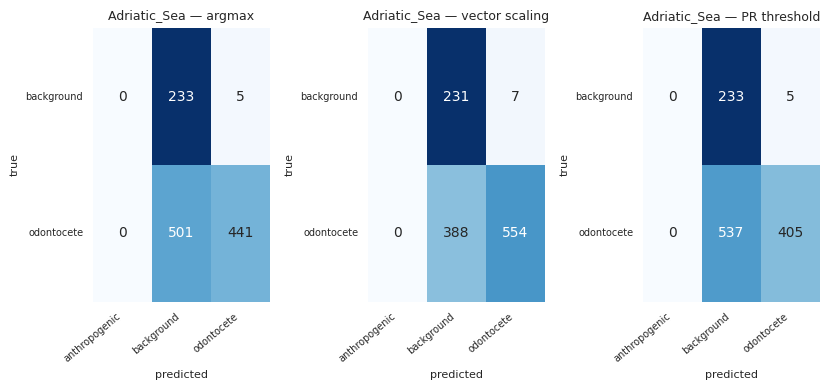


  DCLDE_2026  |  T=2.115  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.604     0.604     0.593     0.612
  balanced accuracy                          0.597     0.597     0.591     0.599
  --- species rows only ---             
  species recall (macro)                     0.332     0.332     0.371     0.280
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.498     0.498     0.541     0.438
  inter-species confusion                    0.008     0.008     0.012     0.002
  hallucination rate                         0.008     0.008     0.012     0.002


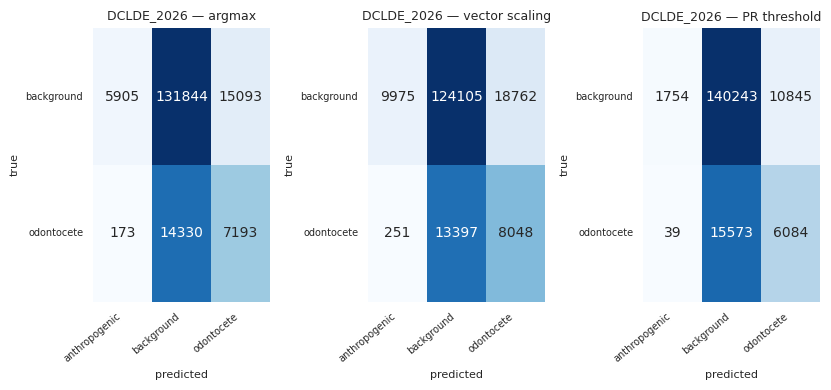


  DOLPHINFREE  |  T=1.389  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.777     0.777     0.717     0.809
  balanced accuracy                          0.817     0.817     0.768     0.841
  --- species rows only ---             
  species recall (macro)                     0.950     0.950     0.938     0.931
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.974     0.974     0.968     0.964
  inter-species confusion                    0.000     0.000     0.000     0.000
  hallucination rate                         0.000     0.000     0.000     0.000


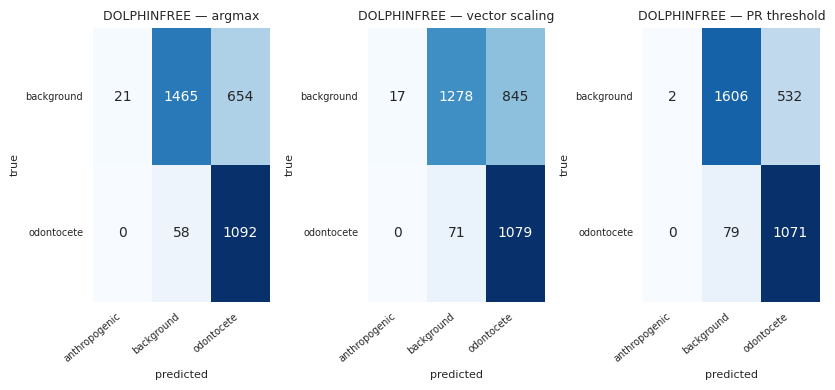


  DRYAD  |  T=2.625  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.764     0.764     0.728     0.762
  balanced accuracy                          0.746     0.746     0.721     0.747
  --- species rows only ---             
  species recall (macro)                     0.702     0.702     0.795     0.698
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.825     0.825     0.886     0.822
  inter-species confusion                    0.097     0.097     0.094     0.073
  hallucination rate                         0.097     0.097     0.094     0.073


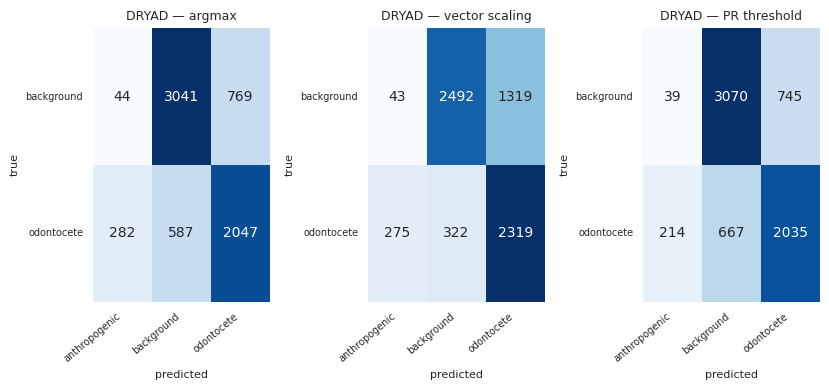


  ECOSS_testtrain  |  T=1.502  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.679     0.679     0.637     0.696
  balanced accuracy                          0.837     0.837     0.838     0.837
  --- species rows only ---             
  species recall (macro)                     0.780     0.780     0.827     0.764
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.876     0.876     0.905     0.866
  inter-species confusion                    0.000     0.000     0.000     0.000
  hallucination rate                         0.000     0.000     0.000     0.000


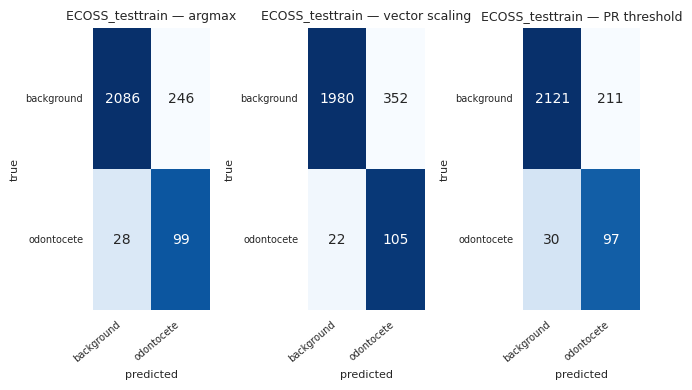


  OLTREMARE  |  T=1.558  |  classes: ['background', 'odontocete']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.807     0.807     0.708     0.811
  balanced accuracy                          0.806     0.806     0.786     0.805
  --- species rows only ---             
  species recall (macro)                     0.679     0.679     0.789     0.668
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.809     0.809     0.882     0.801
  inter-species confusion                    0.002     0.002     0.000     0.000
  hallucination rate                         0.002     0.002     0.000     0.000


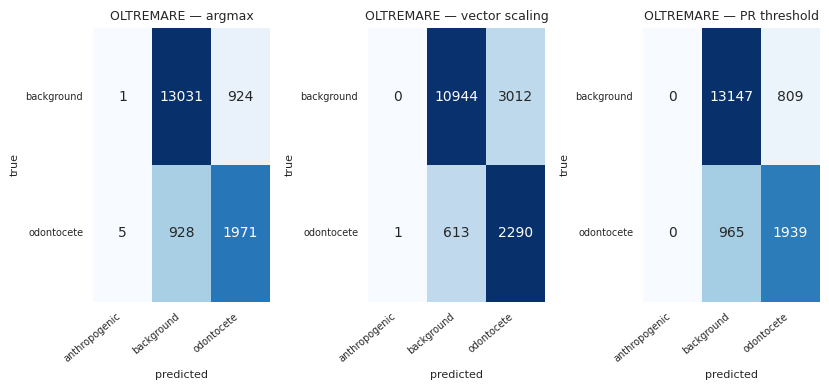

In [18]:
for ds, r in results_l2.items():
    report_fold(r, bg_label='background')

In [19]:
summary_l2 = make_summary_df(results_l2, 'L2-coarse')
print(summary_l2[[
    'held_out','n_test','n_classes_test',
    'argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall',
    'argmax_sp_prec','vec_sp_prec','pr_thresh_sp_prec',
    'argmax_sp_f1','vec_sp_f1','pr_thresh_sp_f1',
    'argmax_hallucin','vec_hallucin','pr_thresh_hallucin',
]].to_string(index=False))
summary_l2.to_csv(OUT_DIR / 'summary_l2_limited_species.csv', index=False)


       held_out  n_test  n_classes_test  argmax_sp_recall  vec_sp_recall  pr_thresh_sp_recall  argmax_sp_prec  vec_sp_prec  pr_thresh_sp_prec  argmax_sp_f1  vec_sp_f1  pr_thresh_sp_f1  argmax_hallucin  vec_hallucin  pr_thresh_hallucin
    DOLPHINFREE    3290               2          0.949565       0.938261             0.931304             1.0          1.0                1.0      0.974130   0.968147         0.964430         0.000000      0.000000            0.000000
ECOSS_testtrain    2459               2          0.779528       0.826772             0.763780             1.0          1.0                1.0      0.876106   0.905172         0.866071         0.000000      0.000000            0.000000
          DRYAD    6770               2          0.701989       0.795267             0.697874             1.0          1.0                1.0      0.824904   0.885960         0.822056         0.096708      0.094307            0.073388
      OLTREMARE   16860               2          0.678719   

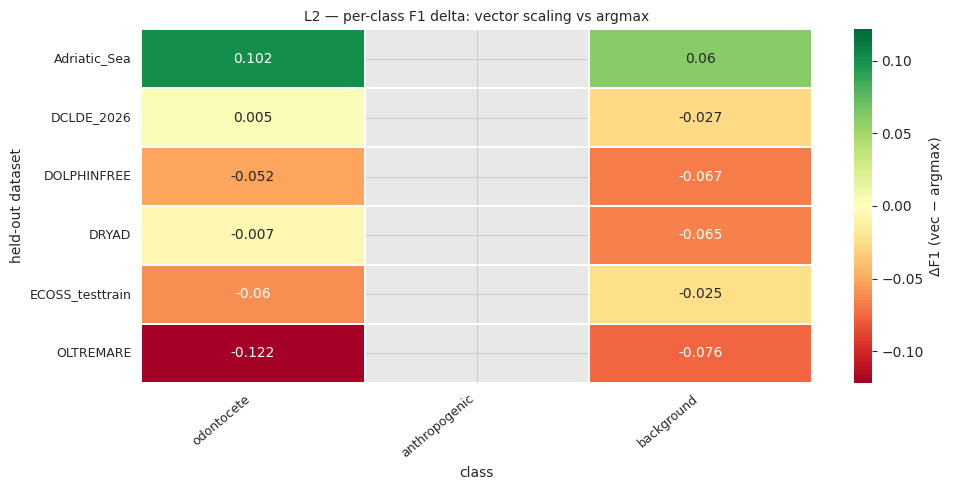


Mean ΔF1 per class (vec − argmax):
class
background      -0.033
odontocete      -0.022
anthropogenic      NaN


In [20]:
_ = per_class_delta_heatmap(
    results_l2, 'vec', 'argmax',
    title='L2 — per-class F1 delta: vector scaling vs argmax',
    out_path=OUT_DIR / 'l2_vec_delta_heatmap_limited_species.png',
    bg_label='background'
)

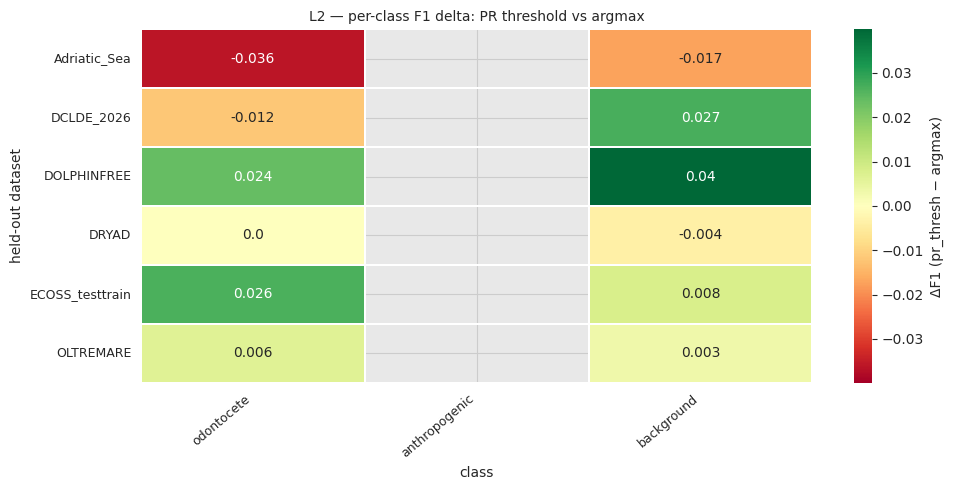


Mean ΔF1 per class (pr_thresh − argmax):
class
odontocete       0.001
background       0.009
anthropogenic      NaN


In [21]:
_ = per_class_delta_heatmap(
    results_l2, 'pr_thresh', 'argmax',
    title='L2 — per-class F1 delta: PR threshold vs argmax',
    out_path=OUT_DIR / 'l2_pr_thresh_delta_heatmap_limited_species.png',
    bg_label='background'
)


## 9. Level 4 — species LODO

86% background, 10 species. Vector scaling calibrated on species-positive
val rows only. The `w` heatmap shows how much each species was sharpened
(`w > 1`) or flattened (`w < 1`) — background should consistently show `w < 1`
and rare species should show `w > 1` if the calibration is working correctly.

In [22]:
L4_HOLDOUTS = sorted(meta_l4['dataset'].unique().tolist())
print(f"{len(L4_HOLDOUTS)} holdouts: {L4_HOLDOUTS}")
results_l4 = run_lodo_level(
    meta_l4, 'label', 'L4-species', L4_HOLDOUTS,
    bg_label='background',
    species_only_fit=True,
    verbose=True
)

6 holdouts: ['Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_testtrain', 'OLTREMARE']


L4-species LODO:   0%|          | 0/6 [00:00<?, ?it/s]


  [Adriatic_Sea] train classes (4): ['Delphinus_delphis', 'Orcinus_orca', 'Tursiops_truncatus', 'background']
  [Adriatic_Sea] test composition:
      Tursiops_truncatus                  n=   942  (OK)
      background                          n=   238  (OK)
  [Adriatic_Sea] train=207,692  val=29,764  (sp_val=3,909)  test=1,180
  [Adriatic_Sea] T=1.986
  [Adriatic_Sea] vector scales:
      Delphinus_delphis                    w=+1.132  b=+0.472
      Orcinus_orca                         w=+0.338  b=+0.244
      Tursiops_truncatus                   w=+0.418  b=+0.517
      background                           w=+0.415  b=-1.233
  [Adriatic_Sea] PR thresholds:
      background                           thr=0.000  n_val=25855
      Orcinus_orca                         thr=0.599  n_val=2918
      Delphinus_delphis                    thr=0.637  n_val=42
      Tursiops_truncatus                   thr=0.974  n_val=949

  [DCLDE_2026] train classes (4): ['Delphinus_delphis', 'Orcinus_orca', '


  Adriatic_Sea  |  T=1.986  |  classes: ['Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.480     0.480     0.604     0.280
  balanced accuracy                          0.662     0.662     0.731     0.552
  --- species rows only ---             
  species recall (macro)                     0.349     0.349     0.500     0.107
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.518     0.518     0.667     0.194
  inter-species confusion                    0.045     0.045     0.104     0.028
  hallucination rate                         0.045     0.045     0.104     0.028


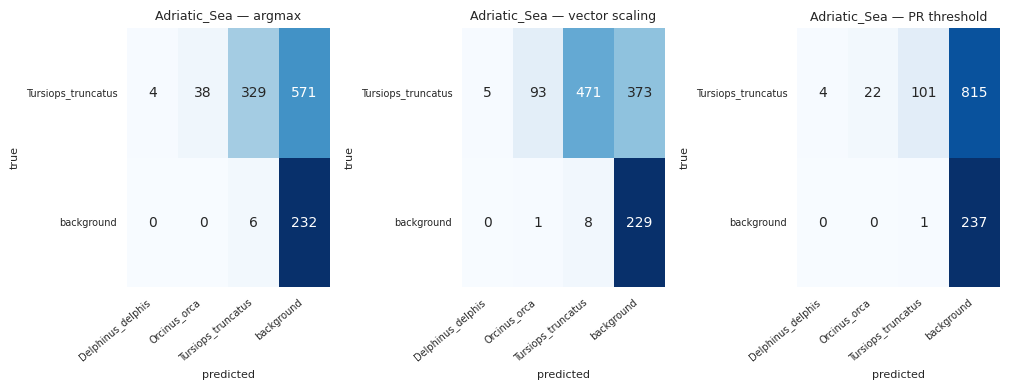


  DCLDE_2026  |  T=1.626  |  classes: ['Orcinus_orca', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.484     0.484     0.483     0.464
  balanced accuracy                          0.492     0.492     0.461     0.485
  --- species rows only ---             
  species recall (macro)                     0.022     0.022     0.041     0.000
  species precision (macro)                  1.000     1.000     1.000     0.000
  species macro F1                           0.043     0.043     0.079     0.000
  inter-species confusion                    0.141     0.141     0.273     0.133
  hallucination rate                         0.141     0.141     0.273     0.133


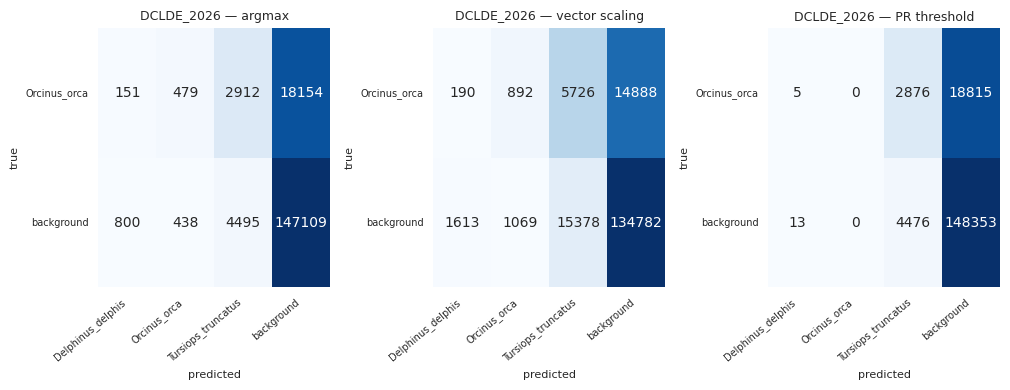


  DOLPHINFREE  |  T=1.407  |  classes: ['Delphinus_delphis', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.400     0.400     0.263     0.430
  balanced accuracy                          0.341     0.341     0.179     0.389
  --- species rows only ---             
  species recall (macro)                     0.000     0.000     0.000     0.000
  species precision (macro)                  0.000     0.000     0.000     0.000
  species macro F1                           0.000     0.000     0.000     0.000
  inter-species confusion                    0.962     0.962     0.992     0.942
  hallucination rate                         0.962     0.962     0.992     0.942


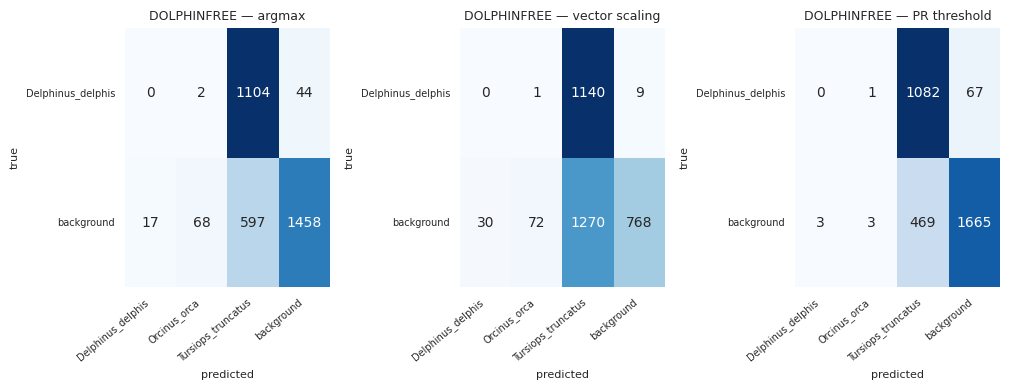


  DRYAD  |  T=1.294  |  classes: ['Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.685     0.685     0.584     0.701
  balanced accuracy                          0.625     0.625     0.583     0.687
  --- species rows only ---             
  species recall (macro)                     0.594     0.594     0.769     0.531
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.745     0.745     0.870     0.693
  inter-species confusion                    0.238     0.238     0.150     0.049
  hallucination rate                         0.238     0.238     0.150     0.049


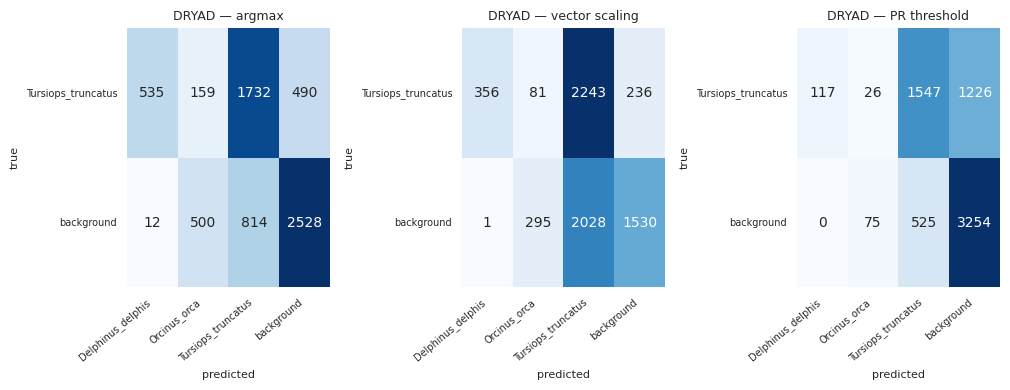


  ECOSS_testtrain  |  T=1.942  |  classes: ['Delphinus_delphis', 'Orcinus_orca', 'Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.378     0.378     0.256     0.374
  balanced accuracy                          0.666     0.666     0.693     0.623
  --- species rows only ---             
  species recall (macro)                     0.557     0.557     0.622     0.499
  species precision (macro)                  0.656     0.656     0.667     0.661
  species macro F1                           0.499     0.499     0.527     0.409
  inter-species confusion                    0.395     0.395     0.420     0.383
  hallucination rate                         0.000     0.000     0.000     0.000


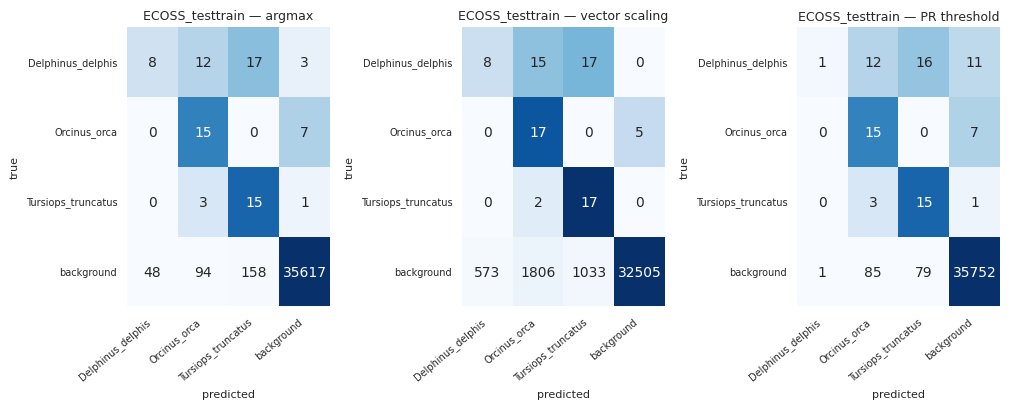


  OLTREMARE  |  T=1.803  |  classes: ['Tursiops_truncatus', 'background']
  metric                                    argmax      temp       vec    pr_thr
  ------------------------------------------------------------------------------
  macro F1 (test classes)                    0.822     0.822     0.679     0.830
  balanced accuracy                          0.800     0.800     0.784     0.801
  --- species rows only ---             
  species recall (macro)                     0.671     0.671     0.871     0.646
  species precision (macro)                  1.000     1.000     1.000     1.000
  species macro F1                           0.803     0.803     0.931     0.785
  inter-species confusion                    0.031     0.031     0.013     0.014
  hallucination rate                         0.031     0.031     0.013     0.014


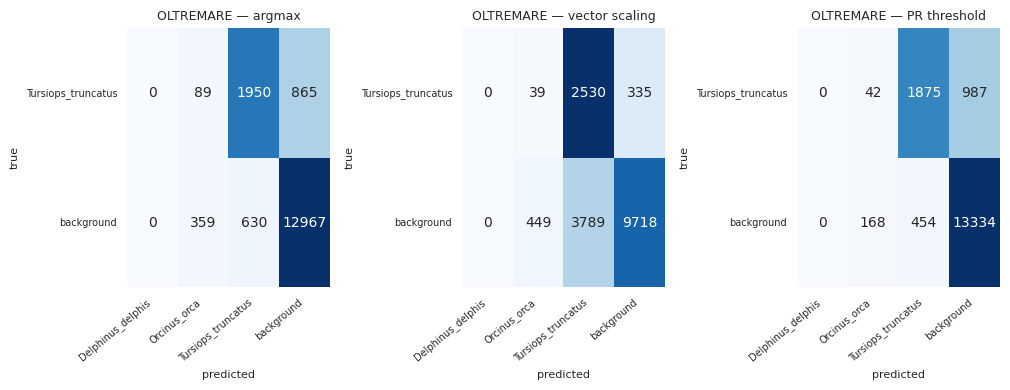

In [23]:
for ds, r in results_l4.items():
    report_fold(r, bg_label='background')

In [24]:
summary_l4 = make_summary_df(results_l4, 'L4-species')
print('\nLevel 4 — species-only metrics (all strategies):')
print(summary_l4[[
    'held_out','n_test','n_classes_test','sp_n_rows',
    'argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall',
    'argmax_sp_prec','vec_sp_prec','pr_thresh_sp_prec',
    'argmax_sp_f1','vec_sp_f1','pr_thresh_sp_f1',
    'argmax_hallucin','vec_hallucin','pr_thresh_hallucin',
    'temperature',
]].to_string(index=False))
summary_l4.to_csv(OUT_DIR / 'summary_l4_limited_species.csv', index=False)



Level 4 — species-only metrics (all strategies):
       held_out  n_test  n_classes_test  sp_n_rows  argmax_sp_recall  vec_sp_recall  pr_thresh_sp_recall  argmax_sp_prec  vec_sp_prec  pr_thresh_sp_prec  argmax_sp_f1  vec_sp_f1  pr_thresh_sp_f1  argmax_hallucin  vec_hallucin  pr_thresh_hallucin  temperature
      OLTREMARE   16860               2       2904          0.671488       0.871212             0.645661         1.00000     1.000000            1.00000      0.803461   0.931174         0.784683         0.030647      0.013430            0.014463        1.803
          DRYAD    6770               2       2916          0.593964       0.769204             0.530521         1.00000     1.000000            1.00000      0.745267   0.869548         0.693256         0.237997      0.149863            0.049040        1.294
ECOSS_testtrain   35998               4         81          0.557097       0.622488             0.498764         0.65625     0.666667            0.66129      0.499497   0.52

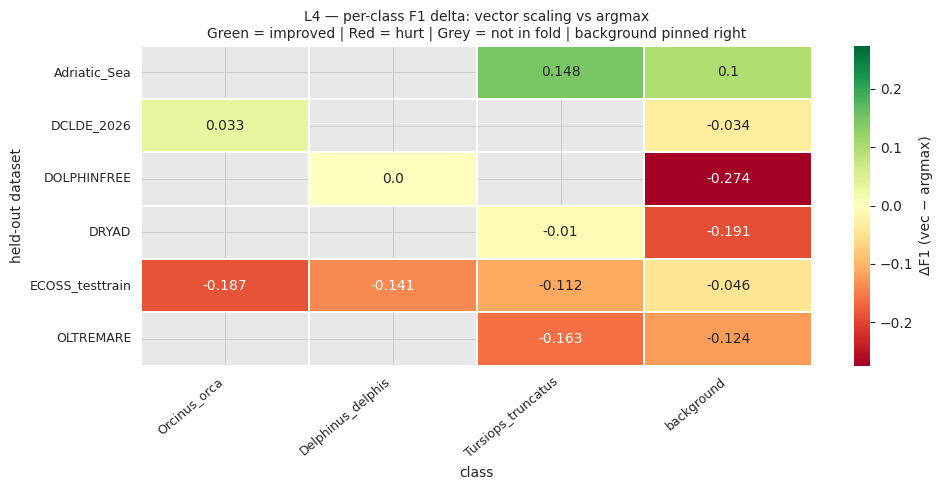


Mean ΔF1 per class (vec − argmax):
class
background           -0.095
Orcinus_orca         -0.077
Delphinus_delphis    -0.070
Tursiops_truncatus   -0.034


In [25]:
_ = per_class_delta_heatmap(
    results_l4, 'vec', 'argmax',
    title='L4 — per-class F1 delta: vector scaling vs argmax\n'
          'Green = improved | Red = hurt | Grey = not in fold | background pinned right',
    out_path=OUT_DIR / 'l4_vec_delta_heatmap_limited_species.png',
    bg_label='background'
)

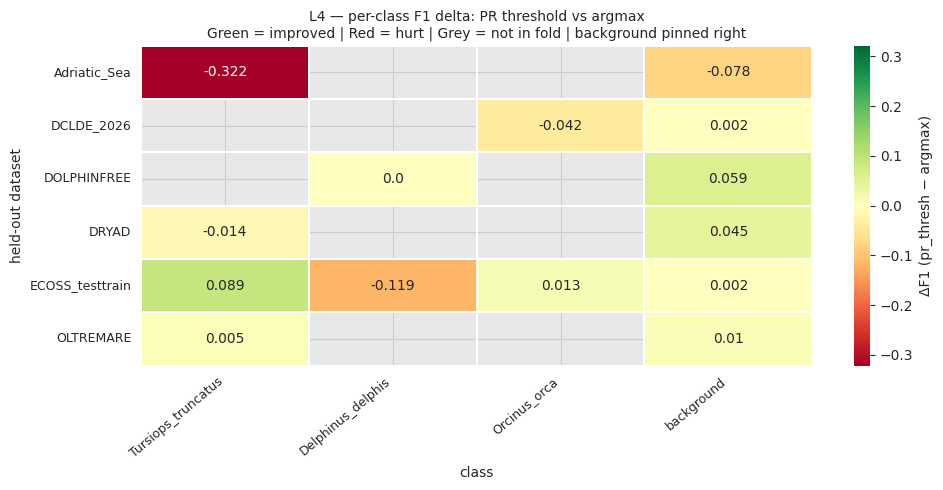


Mean ΔF1 per class (pr_thresh − argmax):
class
Tursiops_truncatus   -0.060
Delphinus_delphis    -0.060
Orcinus_orca         -0.014
background            0.007


In [26]:
_ = per_class_delta_heatmap(
    results_l4, 'pr_thresh', 'argmax',
    title='L4 — per-class F1 delta: PR threshold vs argmax\n'
          'Green = improved | Red = hurt | Grey = not in fold | background pinned right',
    out_path=OUT_DIR / 'l4_pr_thresh_delta_heatmap_limited_species.png',
    bg_label='background'
)


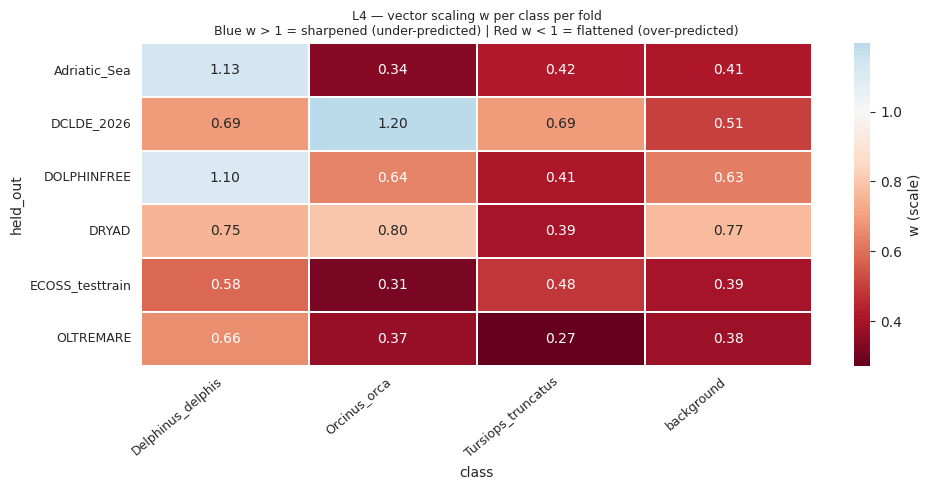

In [27]:
# ── Vector w heatmap ─────────────────────────────────────────────────────────
w_rows = []
for ds, r in results_l4.items():
    for c_name, w_val in zip(r['class_names'], r['vec_w']):
        w_rows.append({'held_out': ds, 'class': c_name, 'w': float(w_val)})

w_pivot = pd.DataFrame(w_rows).pivot(index='held_out', columns='class', values='w')
sp_cols = [c for c in w_pivot.columns if c != 'background']
w_pivot = w_pivot[sorted(sp_cols) + (['background'] if 'background' in w_pivot.columns else [])]

fig, ax = plt.subplots(figsize=(max(10, 0.8*len(w_pivot.columns)+2),
                                 max(5, 0.5*len(w_pivot)+1.5)))
sns.heatmap(w_pivot, cmap='RdBu', center=1.0, annot=True, fmt='.2f',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'w (scale)'})
ax.set_title(
    'L4 — vector scaling w per class per fold\n'
    'Blue w > 1 = sharpened (under-predicted) | Red w < 1 = flattened (over-predicted)',
    fontsize=9)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'l4_vec_w_heatmap_limited_species.png', dpi=150, bbox_inches='tight')
plt.show()

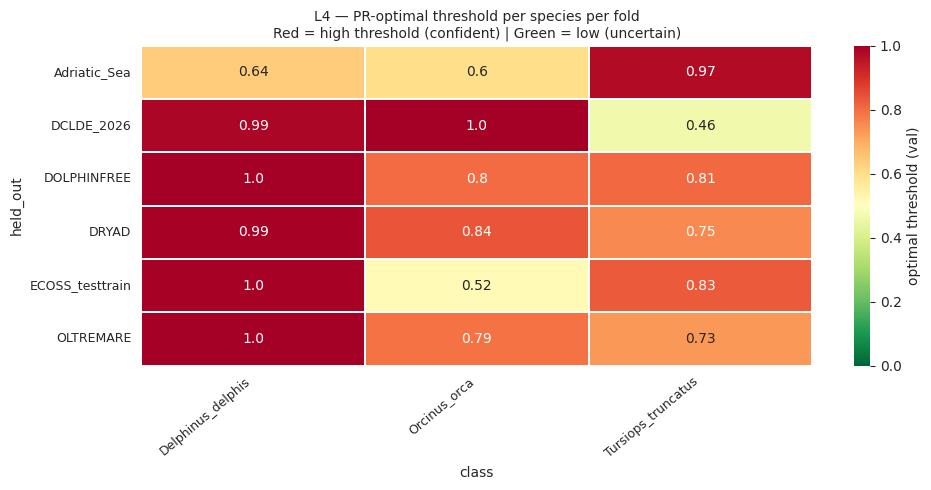

In [28]:
# ── PR threshold heatmap: what threshold was fit per species per fold ────────
thr_rows = []
for ds, r in results_l4.items():
    for cls_name, thr in r['pr_thresholds'].items():
        if cls_name == 'background': continue
        thr_rows.append({'held_out': ds, 'class': cls_name, 'threshold': thr})

thr_pivot = pd.DataFrame(thr_rows).pivot(index='held_out', columns='class', values='threshold')

fig, ax = plt.subplots(figsize=(max(10, 0.8*len(thr_pivot.columns)+2),
                                 max(5,  0.5*len(thr_pivot)+1.5)))
sns.heatmap(thr_pivot, cmap='RdYlGn_r', vmin=0, vmax=1,
            annot=thr_pivot.round(2), fmt='', linewidths=0.3, ax=ax,
            mask=thr_pivot.isna(), cbar_kws={'label': 'optimal threshold (val)'})
ax.set_facecolor('#e8e8e8')
ax.set_title('L4 — PR-optimal threshold per species per fold\n'
             'Red = high threshold (confident) | Green = low (uncertain)',
             fontsize=10)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'l4_pr_threshold_heatmap_limited_species.png', dpi=150, bbox_inches='tight')
plt.show()


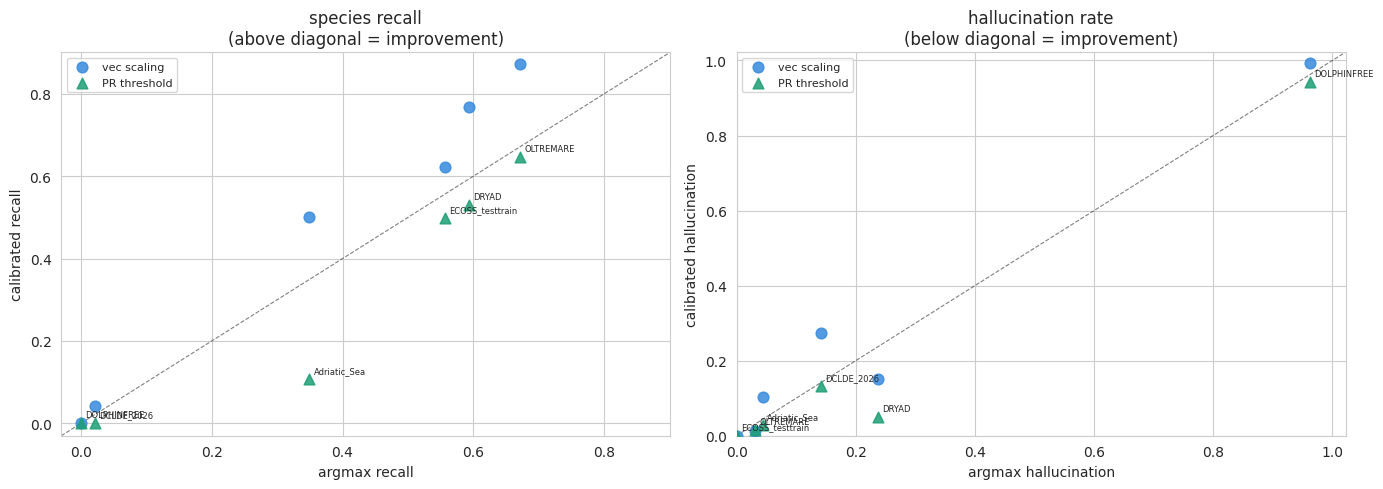

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sub = summary_l4.dropna(subset=['argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall'])
lim = [min(sub[['argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall']].min()) - 0.03,
       max(sub[['argmax_sp_recall','vec_sp_recall','pr_thresh_sp_recall']].max()) + 0.03]
ax.scatter(sub['argmax_sp_recall'], sub['vec_sp_recall'],
           s=60, color='#378ADD', alpha=0.85, zorder=3, label='vec scaling')
ax.scatter(sub['argmax_sp_recall'], sub['pr_thresh_sp_recall'],
           s=60, color='#1D9E75', alpha=0.85, zorder=3, marker='^', label='PR threshold')
for _, row in sub.iterrows():
    ax.annotate(row['held_out'], (row['argmax_sp_recall'], row['pr_thresh_sp_recall']),
                fontsize=6, ha='left', va='bottom', xytext=(3,3), textcoords='offset points')
ax.plot(lim, lim, 'k--', linewidth=0.8, alpha=0.5)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('argmax recall'); ax.set_ylabel('calibrated recall')
ax.set_title('species recall\n(above diagonal = improvement)')
ax.legend(fontsize=8)

ax = axes[1]
sub2 = summary_l4.dropna(subset=['argmax_hallucin','vec_hallucin','pr_thresh_hallucin'])
lim2 = [0, max(sub2[['argmax_hallucin','vec_hallucin','pr_thresh_hallucin']].max()) + 0.03]
ax.scatter(sub2['argmax_hallucin'], sub2['vec_hallucin'],
           s=60, color='#378ADD', alpha=0.85, zorder=3, label='vec scaling')
ax.scatter(sub2['argmax_hallucin'], sub2['pr_thresh_hallucin'],
           s=60, color='#1D9E75', alpha=0.85, zorder=3, marker='^', label='PR threshold')
for _, row in sub2.iterrows():
    ax.annotate(row['held_out'], (row['argmax_hallucin'], row['pr_thresh_hallucin']),
                fontsize=6, ha='left', va='bottom', xytext=(3,3), textcoords='offset points')
ax.plot(lim2, lim2, 'k--', linewidth=0.8, alpha=0.5)
ax.set_xlim(lim2); ax.set_ylim(lim2)
ax.set_xlabel('argmax hallucination'); ax.set_ylabel('calibrated hallucination')
ax.set_title('hallucination rate\n(below diagonal = improvement)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'recall_hallucin_scatter_limited_species.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
all_summary = pd.concat([summary_l2, summary_l4], ignore_index=True)
all_summary.to_csv(OUT_DIR / 'summary_all_levels.csv', index=False)

print('Mean species metrics by level and strategy:')
rows_out = []
for level, df in [('L2', summary_l2), ('L4', summary_l4)]:
    for strat, rcol, pcol, fcol, hcol in [
        ('argmax',    'argmax_sp_recall',    'argmax_sp_prec',    'argmax_sp_f1',    'argmax_hallucin'),
        ('temp',      'temp_sp_recall',      'temp_sp_prec',      'temp_sp_f1',      None),
        ('vec',       'vec_sp_recall',       'vec_sp_prec',       'vec_sp_f1',       'vec_hallucin'),
        ('pr_thresh', 'pr_thresh_sp_recall', 'pr_thresh_sp_prec', 'pr_thresh_sp_f1', 'pr_thresh_hallucin'),
    ]:
        sub = df.dropna(subset=[rcol, pcol, fcol])
        if sub.empty: continue
        row = {'level': level, 'strategy': strat,
               'mean_recall':    round(sub[rcol].mean(), 4),
               'mean_precision': round(sub[pcol].mean(), 4),
               'mean_sp_f1':     round(sub[fcol].mean(), 4)}
        if hcol:
            row['mean_hallucin'] = round(sub[hcol].dropna().mean(), 4)
        rows_out.append(row)
print(pd.DataFrame(rows_out).to_string(index=False))


Mean species metrics by level and strategy:
level  strategy  mean_recall  mean_precision  mean_sp_f1  mean_hallucin
   L2    argmax       0.6516          1.0000      0.7699         0.0177
   L2      temp       0.6516          1.0000      0.7699            NaN
   L2       vec       0.7180          1.0000      0.8205         0.0177
   L2 pr_thresh       0.6285          1.0000      0.7488         0.0125
   L4    argmax       0.3656          0.7760      0.4349         0.2360
   L4      temp       0.3656          0.7760      0.4349            NaN
   L4       vec       0.4673          0.7778      0.5123         0.2554
   L4 pr_thresh       0.2970          0.6102      0.3467         0.1943


## 10. Persist artefacts

In [31]:
def save_preds(name, r):
    rows_te     = r.get('rows_te')
    class_names = r.get('class_names')
    if rows_te is None or class_names is None: return
    df = meta_all.iloc[rows_te][[
        'dataset','region','environment','group_key',
        'label_t1','label_t2','label_t3','label_t4'
    ]].copy()
    df['y_true']      = [class_names[i] for i in r['yte']]
    df['y_argmax']    = [class_names[i] for i in r['y_argmax']]
    df['y_temp']      = [class_names[i] for i in r['y_temp']]
    df['y_vec']       = [class_names[i] for i in r['y_vec']]
    df['y_pr_thresh'] = [class_names[i] for i in r['y_pr_thresh']]
    for ci, cn in enumerate(class_names):
        df[f'prob_raw_{cn}'] = r['proba_raw'][:, ci]
        df[f'prob_vec_{cn}'] = r['proba_vec'][:, ci]
    fp = OUT_DIR / f'preds_{name}.parquet'
    df.to_parquet(fp, index=False)
    print(f"  {fp.name}  ({len(df):,} rows)")

print('Level 2:'); [save_preds(f'l2_{ds}', r) for ds, r in results_l2.items()]
print('Level 4:'); [save_preds(f'l4_{ds}', r) for ds, r in results_l4.items()]

# save per-fold PR thresholds as JSON
all_thresholds = {ds: r['pr_thresholds'] for ds, r in results_l4.items()}
with open(OUT_DIR / 'l4_pr_thresholds_per_fold_limited_species.json', 'w') as f:
    json.dump(all_thresholds, f, indent=2)
print(f'\nPR thresholds  → {OUT_DIR}/l4_pr_thresholds_per_fold_limited_species.json')
print(f'All artefacts  → {OUT_DIR.resolve()}')


Level 2:
  preds_l2_Adriatic_Sea.parquet  (1,180 rows)
  preds_l2_DCLDE_2026.parquet  (174,538 rows)
  preds_l2_DOLPHINFREE.parquet  (3,290 rows)
  preds_l2_DRYAD.parquet  (6,770 rows)
  preds_l2_ECOSS_testtrain.parquet  (2,459 rows)


IndexError: positional indexers are out-of-bounds